In [5]:
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, gen_spider_plot

# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [6]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "analysis/n_100/"
pdf_file = "analysis/n_100/scaling_results-100.pdf"
plt_figs = []

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)

In [7]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['GD', 'BC', 'CC', 'EC']

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


PAN/CGO (exponential fit): KS=inf, p-value=0.00
PAN/CGO (log-normal fit): KS=0.06, p-value=1.00

Carb. PAN (exponential fit): KS=inf, p-value=0.00
Carb. PAN (log-normal fit): KS=0.06, p-value=1.00

PAN (exponential fit): KS=inf, p-value=0.00
PAN (log-normal fit): KS=0.06, p-value=1.00

Carb. PAN/CGO (exponential fit): KS=inf, p-value=0.00
Carb. PAN/CGO (log-normal fit): KS=0.06, p-value=1.00



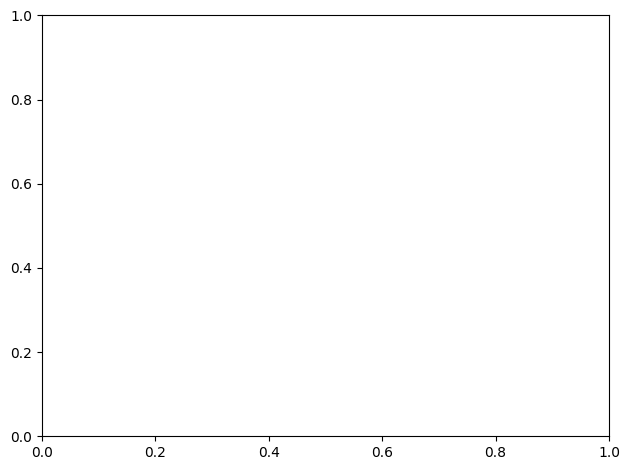

In [8]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']



fig = plt.Figure(figsize=(11, 8.5), dpi=300)
ax2 = fig.add_subplot(2, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_dens[df_dens['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.3f}, p-val={res.pvalue:.3f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    res_3 = stats.goodness_of_fit(stats.lognorm, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (log-normal fit): KS={res_3.statistic:.2f}, p-value={res_3.pvalue:.2f}\n")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Graph Density')
ax2.set_title('Nodes vs Graph Density (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.56, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
#fig.show()

plt_figs.append(fig)

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


PAN/CGO (exponential fit): KS=inf, p-value=0.00
PAN/CGO (log-normal fit): KS=0.17, p-value=0.92

Carb. PAN (exponential fit): KS=inf, p-value=0.00
Carb. PAN (log-normal fit): KS=0.18, p-value=0.91

PAN (exponential fit): KS=inf, p-value=0.00
PAN (log-normal fit): KS=0.19, p-value=0.89

Carb. PAN/CGO (exponential fit): KS=inf, p-value=0.00
Carb. PAN/CGO (log-normal fit): KS=0.17, p-value=0.93



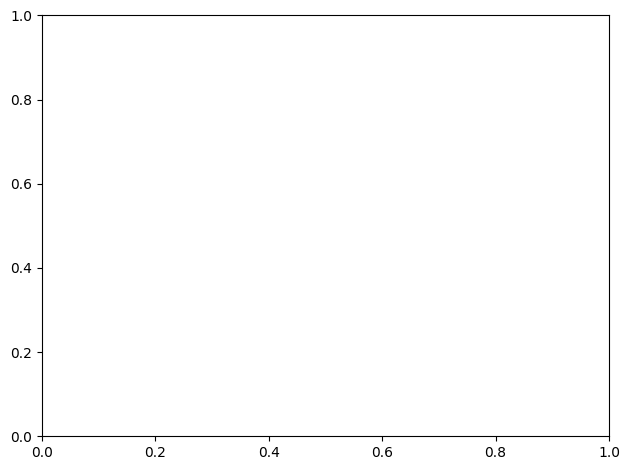

In [9]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']


fig = plt.Figure(figsize=(11, 8.5), dpi=300)
ax2 = fig.add_subplot(2, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_bet[df_bet['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    res_3 = stats.goodness_of_fit(stats.lognorm, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (log-normal fit): KS={res_3.statistic:.2f}, p-value={res_3.pvalue:.2f}\n")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Betweenness Centrality')
ax2.set_title('Nodes vs Betweenness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
#fig.show()

plt_figs.append(fig)

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


PAN/CGO (exponential fit): KS=inf, p-value=0.00
PAN/CGO (log-normal fit): KS=0.22, p-value=0.77

Carb. PAN (exponential fit): KS=inf, p-value=0.00
Carb. PAN (log-normal fit): KS=0.25, p-value=0.70

PAN (exponential fit): KS=inf, p-value=0.00
PAN (log-normal fit): KS=0.23, p-value=0.74

Carb. PAN/CGO (exponential fit): KS=inf, p-value=0.00
Carb. PAN/CGO (log-normal fit): KS=0.24, p-value=0.73



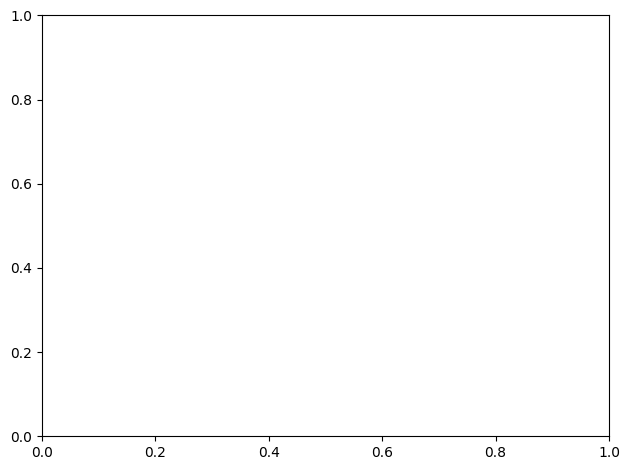

In [10]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']


fig = plt.Figure(figsize=(11, 8.5), dpi=300)
ax2 = fig.add_subplot(2, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_clo[df_clo['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    res_3 = stats.goodness_of_fit(stats.lognorm, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (log-normal fit): KS={res_3.statistic:.2f}, p-value={res_3.pvalue:.2f}\n")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Closeness Centrality')
ax2.set_title('Nodes vs Closeness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
#plt.show()

plt_figs.append(fig)

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


PAN/CGO (exponential fit): KS=inf, p-value=0.00
PAN/CGO (log-normal fit): KS=0.10, p-value=1.00

Carb. PAN (exponential fit): KS=inf, p-value=0.00
Carb. PAN (log-normal fit): KS=0.13, p-value=0.98

PAN (exponential fit): KS=inf, p-value=0.00
PAN (log-normal fit): KS=0.22, p-value=0.84

Carb. PAN/CGO (exponential fit): KS=inf, p-value=0.00
Carb. PAN/CGO (log-normal fit): KS=0.40, p-value=0.33



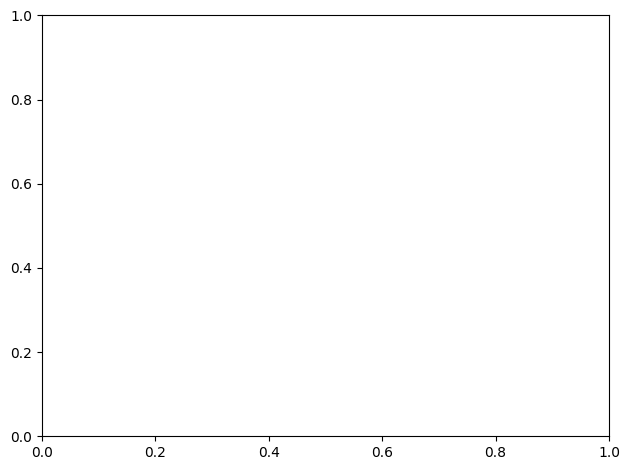

In [11]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']




fig = plt.Figure(figsize=(11, 8.5), dpi=300)
ax2 = fig.add_subplot(2, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_eig[df_eig['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    res_3 = stats.goodness_of_fit(stats.lognorm, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (log-normal fit): KS={res_3.statistic:.2f}, p-value={res_3.pvalue:.2f}\n")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Eigenvector Centrality')
ax2.set_title('Nodes vs Eigenvector Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
#fig.show()

plt_figs.append(fig)

In [12]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)